# CBSA City Profiles

Two functions for per-city analysis:

1. **`plot_degree_distribution(cbsa_code)`** — histogram of node degree for each decade + text file of top-20 highest-degree tracts.
2. **`plot_graph(cbsa_code, overlay_shapefile=False)`** — one graph visualisation PNG per decade, with optional shapefile underlay.

In [182]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd

YEARS                  = [1980, 1990, 2000, 2010, 2020]
CBSA_DIR               = '../study_areas'
CENSUS_GEOGRAPHY_TYPE  = 'block_groups'  # 'tracts' or 'block_groups'
VINTAGE                = None       # None = all vintages; set e.g. 'march_2020' to restrict
OUT_DIR                = None       # set automatically in the CBSA cell below

_SCORE_CSV_DIRS = {
    'tracts':       '../outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage',
    'block_groups': '../outputs/block_groups_in_cbsa_2020-2010-2000-1990_years_march_2020_vintage',
}
SCORE_CSV_DIR = _SCORE_CSV_DIRS[CENSUS_GEOGRAPHY_TYPE]

_cbsa_df = pd.read_csv('cbsa-name dictionary.csv')
cbsa_dict = dict(zip(_cbsa_df['CBSA Code'], _cbsa_df['CBSA Name']))

In [183]:
def find_files(cbsa_code, vintage=VINTAGE):
    """
    Return {year: filepath} for every decade that has a connected JSON for this CBSA.
    Files: study_areas/{year}/{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_{code}_{year}_{vintage}_vintage_connected.json
    """
    found = {}
    for yr in YEARS:
        pattern = os.path.join(
            CBSA_DIR, str(yr),
            f'{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_{cbsa_code}_{yr}_*_vintage_connected.json'
        )
        matches = sorted(glob.glob(pattern))
        if vintage:
            matches = [m for m
             in matches if vintage in os.path.basename(m)]
        if matches:
            found[yr] = matches[0]
    return found


def load_graph(filepath):
    """
    Load a connected JSON and return (nodes_dict, nx.Graph).
    nodes_dict: {node_id: attribute_dict}
    Graph nodes are keyed by their 'id' attribute to stay consistent
    with the adjacency references.
    """
    with open(filepath) as f:
        d = json.load(f)
    nodes_list = d['nodes']

    nodes = {node['id']: node for node in nodes_list}
    G = nx.Graph()
    for node_id, attrs in nodes.items():
        G.add_node(node_id, **attrs)

    for i, neighbours in enumerate(d['adjacency']):
        src_id = nodes_list[i]['id']
        for nb in neighbours:
            j = nb['id']
            if src_id < j:
                G.add_edge(src_id, j, shared_perim=nb.get('shared_perim', 1))

    return nodes, G

In [184]:
def plot_degree_distribution(cbsa_code, vintage=VINTAGE, out_dir=None):
    """
    For each available decade, plot the degree distribution of the CBSA graph.
    Produces a 3-row figure (all / ≤ Tukey threshold / ≥ Tukey threshold).
    Prints per-year leaf counts and degree summary statistics.
    """
    if out_dir is None:
        out_dir = OUT_DIR
    files = find_files(cbsa_code, vintage=vintage)
    if not files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    years = sorted(files)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    # Load all graphs once
    graphs_by_year = {}
    nodes_by_year = {}
    degrees_by_year = {}
    for yr in years:
        n, G = load_graph(files[yr])
        graphs_by_year[yr] = G
        nodes_by_year[yr] = n
        degrees_by_year[yr] = dict(G.degree())

    # Tukey upper fence from pooled degrees across all years
    all_degrees_flat = [d for yr in years for d in degrees_by_year[yr].values()]
    q1, q3 = np.percentile(all_degrees_flat, [25, 75])
    threshold = q3 + 1.5 * (q3 - q1)
    max_deg_all = max(all_degrees_flat)

    # 3-row figure
    fig, axes = plt.subplots(3, len(years), figsize=(4 * len(years), 3.5 * 3), squeeze=False)
    fig.suptitle(f'Degree Distribution — {cbsa_name}', fontsize=14, fontweight='bold', y=1.02)

    row_labels = [
        f'All  (threshold={threshold:.1f})',
        f'Degree ≤ {threshold:.1f}',
        f'Degree ≥ {threshold:.1f}',
    ]

    for col, yr in enumerate(years):
        vals_all = list(degrees_by_year[yr].values())
        vals_below = [d for d in vals_all if d <= threshold]
        vals_above = [d for d in vals_all if d >= threshold]

        for row, vals in enumerate([vals_all, vals_below, vals_above]):
            ax = axes[row][col]

            if row == 0:
                bins = range(0, max_deg_all + 2)
            elif row == 1:
                bins = range(0, int(threshold) + 2)
            else:
                bins = range(int(threshold), (max(vals) if vals else int(threshold)) + 2)

            if vals:
                ax.hist(vals, bins=bins, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=9)
            else:
                ax.set_yticklabels([])
            if row == 0:
                ax.set_title(str(yr), fontsize=12, fontweight='bold')
            ax.set_xlabel('Degree', fontsize=9)
            ax.tick_params(labelsize=8)
            ax.text(0.97, 0.95, f'n={len(vals):,}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8, color='#555')
            if vals:
                ax.text(0.97, 0.85, f'med={np.median(vals):.1f}', transform=ax.transAxes,
                        ha='right', va='top', fontsize=8, color='#555')

    plt.tight_layout()
    plt.show()

    # Stats printout
    print(f'\nDegree statistics by year — {cbsa_name}  (Tukey threshold = {threshold:.1f})')
    print(f"{'Year':>6}  {'Leaves':>7}  {'Mean':>8}  {'Median':>8}  {'Min':>5}  {'Max':>5}  {'Std':>8}")
    print('-' * 60)
    for yr in years:
        arr = np.array(list(degrees_by_year[yr].values()))
        n_leaves = int((arr == 1).sum())
        print(f"{yr:>6}  {n_leaves:>7}  {arr.mean():>8.2f}  {np.median(arr):>8.2f}  "
              f"{int(arr.min()):>5}  {int(arr.max()):>5}  {arr.std():>8.2f}")

In [185]:
def _node_positions(G):
    pos = {}
    missing = []
    for node_id, attrs in G.nodes(data=True):
        cx = attrs.get('centroid_x')
        cy = attrs.get('centroid_y')
        if cx is not None and cy is not None:
            pos[node_id] = (cx, cy)
        else:
            missing.append(node_id)
    if not pos:
        print('  centroid_x/centroid_y not found on any nodes — falling back to spring layout')
        return nx.spring_layout(G, seed=42)
    if missing:
        print(f'  Warning: {len(missing)} nodes missing centroid attrs — placing at mean centroid')
        mean_x = sum(x for x, y in pos.values()) / len(pos)
        mean_y = sum(y for x, y in pos.values()) / len(pos)
        for node_id in missing:
            pos[node_id] = (mean_x, mean_y)
    return pos


def _moran_p(G, arr):
    if len(G) < 2:
        return np.nan
    n = len(G)
    nodelist = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodelist)
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    P = A / row_sums
    S0 = P.sum()
    if S0 == 0:
        return np.nan
    x = arr.astype(float) - arr.mean()
    denom = float(x @ x)
    if denom == 0:
        return np.nan
    return (n / S0) * float(x @ P @ x) / denom


def _compute_var(G, var):
    raw = []
    for i in G.nodes():
        attrs = G.nodes[i]
        if var == 'Black_Share':
            denom = (attrs.get('BLACK') or 0) + (attrs.get('WHITE') or 0)
            val = (attrs.get('BLACK') or 0) / denom if denom > 0 else np.nan
        elif var == 'Poc_Share':
            totpop = attrs.get('TOTPOP') or 0
            val = (attrs.get('POC') or 0) / totpop if totpop > 0 else np.nan
        else:
            val = attrs.get(var, 0) or 0
        raw.append(val)
    return np.array(raw, dtype=float)


def plot_graph(cbsa_code, overlay_shapefile=False, var=None, vintage=VINTAGE, out_dir=None,
               normalize='local', threshold='maj'):
    """
    normalize : 'local'  — each year uses its own min/max normalization (default)
                'global' — one shared colormap scale across all years
    threshold : 'maj' — cutoff = 0.5; 'avg' — cutoff = per-year mean share
                Applies when var is 'black_share_above_threshold' or
                'poc_share_above_threshold', which colour each node by how far its
                share exceeds the threshold (nodes below threshold shown in grey).
    """
    _ABOVE_THRESH_BASES = {
        'black_share_above_threshold': 'Black_Share',
        'poc_share_above_threshold':   'Poc_Share',
    }
    is_above_thresh = var in _ABOVE_THRESH_BASES

    def _excess_arr(G):
        base   = _compute_var(G, _ABOVE_THRESH_BASES[var])
        cutoff = 0.5 if threshold == 'maj' else float(np.nanmean(base[~np.isnan(base)]))
        return np.where(~np.isnan(base) & (base >= cutoff), base - cutoff, np.nan)

    if out_dir is None:
        out_dir = OUT_DIR
    files = find_files(cbsa_code, vintage=vintage)
    if not files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))
    geo_label = CENSUS_GEOGRAPHY_TYPE.replace('_', ' ')

    if is_above_thresh:
        thresh_label = '50%' if threshold == 'maj' else 'mean'
        base_name    = 'Black' if _ABOVE_THRESH_BASES[var] == 'Black_Share' else 'POC'
        var_disp     = f'{base_name} Share Excess (≥ {thresh_label})'
        cmap         = plt.cm.plasma.copy()
        cmap.set_bad(color='lightgray', alpha=0.6)
    else:
        var_disp = var
        cmap     = plt.cm.plasma

    # Global normalization: pre-compute min/max across all years
    global_min, global_max = None, None
    if var is not None and normalize == 'global':
        all_vals = []
        for fp in files.values():
            _, G = load_graph(fp)
            arr   = _excess_arr(G) if is_above_thresh else _compute_var(G, var)
            valid = arr[~np.isnan(arr)]
            if len(valid):
                all_vals.extend(valid.tolist())
        if all_vals:
            global_min = 0.0 if is_above_thresh else min(all_vals)
            global_max = max(all_vals)

    year_graph_stats = {}
    year_black_share = {}
    year_poc_share   = {}
    year_var_stats   = {}
    year_moran       = {}

    for yr in sorted(files):
        fp = files[yr]
        nodes, G = load_graph(fp)
        pos = _node_positions(G)

        year_graph_stats[yr] = (G.number_of_nodes(), G.number_of_edges())
        year_black_share[yr] = _compute_var(G, 'Black_Share')
        year_poc_share[yr]   = _compute_var(G, 'Poc_Share')

        fig, ax = plt.subplots(figsize=(10, 10))
        ax.set_title(
            f'{cbsa_name} — {yr}  ({G.number_of_nodes()} {geo_label}, {G.number_of_edges()} edges)',
            fontsize=13, fontweight='bold')

        if overlay_shapefile:
            shp_path = fp.replace('_connected.json', '.shp')
            if os.path.exists(shp_path):
                gdf = gpd.read_file(shp_path).to_crs('esri:102003')
                gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#aaaaaa', linewidth=0.5)
            else:
                print(f'  Shapefile not found: {shp_path}')

        node_sizes = [2] * G.number_of_nodes()
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.6, edge_color='#888')

        if var is not None:
            arr = _excess_arr(G) if is_above_thresh else _compute_var(G, var)
            year_var_stats[yr] = arr
            if not is_above_thresh:
                year_moran[yr] = _moran_p(G, arr)

            if normalize == 'global':
                nc = nx.draw_networkx_nodes(G, pos, ax=ax,
                                            node_color=arr, cmap=cmap,
                                            vmin=global_min, vmax=global_max,
                                            node_size=node_sizes, alpha=0.85)
                plt.colorbar(nc, ax=ax, label=f'{var_disp}  ({global_min:.3f}–{global_max:.3f})', shrink=0.6)
            else:
                if is_above_thresh:
                    vmax_l = float(np.nanmax(arr)) if not np.all(np.isnan(arr)) else 1.0
                    nc = nx.draw_networkx_nodes(G, pos, ax=ax,
                                                node_color=arr, cmap=cmap,
                                                vmin=0.0, vmax=vmax_l,
                                                node_size=node_sizes, alpha=0.85)
                    plt.colorbar(nc, ax=ax, label=var_disp, shrink=0.6)
                else:
                    min_v, max_v = np.nanmin(arr), np.nanmax(arr)
                    span = max_v - min_v if max_v != min_v else 1
                    node_colors = ((arr - min_v) / span).tolist()
                    nc = nx.draw_networkx_nodes(G, pos, ax=ax,
                                                node_color=node_colors, cmap=cmap,
                                                node_size=node_sizes, alpha=0.85)
                    plt.colorbar(nc, ax=ax, label=f'{var_disp} (normalised)', shrink=0.6)
        else:
            nx.draw_networkx_nodes(G, pos, ax=ax,
                                   node_color='steelblue',
                                   node_size=node_sizes, alpha=0.85)

        ax.set_axis_off()
        plt.tight_layout()

        mode    = 'overlay' if overlay_shapefile else 'graph'
        var_tag = f'_{var}' if var is not None else ''
        fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{yr}{var_tag}_{mode}.png')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'Saved {fig_path}')
        plt.show()

    # Report
    def _stat_row(arr):
        return (f"{np.nanmean(arr):>10.4f}  {np.nanmedian(arr):>10.4f}  "
                f"{np.nanmin(arr):>10.4f}  {np.nanmax(arr):>10.4f}  {np.nanstd(arr):>10.4f}")

    stat_header = f"{'Year':>6}  {'Mean':>10}  {'Median':>10}  {'Min':>10}  {'Max':>10}  {'Std':>10}"
    stat_sep    = '-' * 63

    text_lines = [f'Graph report — {cbsa_name}', '=' * 70]

    text_lines += ['', 'Graph Structure', f"{'Year':>6}  {'Nodes':>6}  {'Edges':>6}", '-' * 22]
    for yr, (n, e) in sorted(year_graph_stats.items()):
        text_lines.append(f"{yr:>6}  {n:>6}  {e:>6}")

    text_lines += ['', 'Black Share  (BLACK / (BLACK + WHITE))', stat_header, stat_sep]
    for yr, arr in sorted(year_black_share.items()):
        text_lines.append(f"{yr:>6}  {_stat_row(arr)}")

    text_lines += ['', 'POC Share  (POC / TOTPOP)', stat_header, stat_sep]
    for yr, arr in sorted(year_poc_share.items()):
        text_lines.append(f"{yr:>6}  {_stat_row(arr)}")

    if var is not None and year_var_stats:
        if is_above_thresh:
            text_lines += ['', var_disp, stat_header, stat_sep]
            for yr, arr in sorted(year_var_stats.items()):
                text_lines.append(f"{yr:>6}  {_stat_row(arr)}")
        else:
            mp_header = stat_header + f"  {'Moran P':>9}"
            text_lines += ['', var, mp_header, stat_sep + '-' * 12]
            for yr, arr in sorted(year_var_stats.items()):
                mp = year_moran.get(yr, np.nan)
                mp_str = f'{mp:>9.4f}' if not np.isnan(mp) else f'{"n/a":>9}'
                text_lines.append(f"{yr:>6}  {_stat_row(arr)}  {mp_str}")

    print('\n' + '\n'.join(text_lines))
    var_tag = f'_{var}' if var is not None else ''
    txt_path = os.path.join(out_dir, f'cbsa_{cbsa_code}{var_tag}_graph_report.txt')
    with open(txt_path, 'w') as f:
        f.write('\n'.join(text_lines) + '\n')
    print(f'Saved {txt_path}')

In [186]:
def plot_graph_stats(cbsa_code, vintage=VINTAGE, out_dir=None):
    if out_dir is None:
        out_dir = OUT_DIR
    files = find_files(cbsa_code, vintage=vintage)
    if not files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))
    geo_label = CENSUS_GEOGRAPHY_TYPE.replace('_', ' ')

    years_list = []
    poc_mean_list,   poc_global_list   = [], []
    black_mean_list, black_global_list = [], []
    nodes_list, edges_list, max_deg_list, leaves_list = [], [], [], []

    for yr in sorted(files):
        _, G = load_graph(files[yr])
        degrees   = [d for _, d in G.degree()]
        poc_arr   = _compute_var(G, 'Poc_Share')
        black_arr = _compute_var(G, 'Black_Share')

        sum_totpop = sum((G.nodes[n].get('TOTPOP') or 0) for n in G.nodes())
        sum_poc    = sum((G.nodes[n].get('POC')    or 0) for n in G.nodes())
        sum_black  = sum((G.nodes[n].get('BLACK')  or 0) for n in G.nodes())
        sum_white  = sum((G.nodes[n].get('WHITE')  or 0) for n in G.nodes())

        years_list.append(yr)
        poc_mean_list.append(float(np.nanmean(poc_arr)))
        poc_global_list.append(sum_poc / sum_totpop if sum_totpop > 0 else np.nan)
        black_mean_list.append(float(np.nanmean(black_arr)))
        black_global_list.append(sum_black / (sum_black + sum_white) if (sum_black + sum_white) > 0 else np.nan)
        nodes_list.append(G.number_of_nodes())
        edges_list.append(G.number_of_edges())
        max_deg_list.append(max(degrees) if degrees else 0)
        leaves_list.append(sum(1 for d in degrees if d == 1))

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(
        f'{cbsa_name} — Graph Statistics Over Time ({geo_label.title()})',
        fontsize=14, fontweight='bold',
    )

    for ax, vals, title, ylabel in [
        (axes[0, 0], poc_global_list,   'Global POC Share',   'Share'),
        (axes[0, 1], poc_mean_list,     'Mean POC Share',     'Share'),
        (axes[0, 2], black_global_list, 'Global Black Share', 'Share'),
        (axes[0, 3], black_mean_list,   'Mean Black Share',   'Share'),
        (axes[1, 0], nodes_list,        'Number of Nodes',    'Count'),
        (axes[1, 1], edges_list,        'Number of Edges',    'Count'),
        (axes[1, 2], max_deg_list,      'Max Degree',         'Degree'),
        (axes[1, 3], leaves_list,       'Number of Leaves',   'Count'),
    ]:
        ax.plot(years_list, vals, marker='o', linewidth=1.8, color='steelblue')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xticks(years_list)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [187]:
def plot_threshold_counts(cbsa_code, comparison='black', threshold='avg', vintage=VINTAGE, out_dir=None):
    """
    For each decade, print three histograms stacked in rows:
      - Row 0: share values above threshold (x=share, y=count of tracts)
      - Row 1: share values above threshold (x=share, y=% of all tracts)
      - Row 2: total % of tracts above threshold (single bar per decade)

    Parameters
    ----------
    comparison : 'black' or 'poc'
        'black' — use Black_Share (BLACK / (BLACK + WHITE))
        'poc'   — use Poc_Share (POC / TOTPOP)
    threshold : 'avg' or 'maj'
        'avg' — nodes with share >= mean share for that year
        'maj' — nodes with share >= 0.5
    """
    if out_dir is None:
        out_dir = OUT_DIR
    files = find_files(cbsa_code, vintage=vintage)
    if not files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name  = cbsa_dict.get(cbsa_code, str(cbsa_code))
    var        = 'Black_Share' if comparison == 'black' else 'Poc_Share'
    var_label  = 'Black Share' if comparison == 'black' else 'POC Share'
    geo_label  = CENSUS_GEOGRAPHY_TYPE.replace('_', ' ')
    thresh_str = '>= 50%' if threshold == 'maj' else '>= mean'

    results = {}
    for yr in sorted(files):
        _, G = load_graph(files[yr])
        arr    = _compute_var(G, var)
        valid  = arr[~np.isnan(arr)]
        cutoff = 0.5 if threshold == 'maj' else float(np.nanmean(arr))
        above  = valid[valid >= cutoff]
        below  = valid[valid < cutoff]
        results[yr] = {
            'n_total': len(valid),
            'n_above': len(above),
            'n_below': len(below),
            'pct':     100 * len(above) / len(valid) if len(valid) > 0 else 0.0,
            'cutoff':  cutoff,
            'above':   above,
            'valid':   valid,
        }

    years   = sorted(results)
    n_years = len(years)

    fig, axes = plt.subplots(3, n_years, figsize=(4 * n_years, 9), squeeze=False)
    fig.suptitle(
        f'{cbsa_name} — {var_label} {thresh_str}',
        fontsize=13, fontweight='bold',
    )

    # Shared x-range for rows 0 and 1
    all_above = np.concatenate([results[yr]['above'] for yr in years if len(results[yr]['above'])])
    x_min = float(all_above.min()) if len(all_above) else 0.0
    x_max = float(all_above.max()) if len(all_above) else 1.0

    for col, yr in enumerate(years):
        r       = results[yr]
        ax0     = axes[0][col]
        ax1     = axes[1][col]
        ax2     = axes[2][col]
        n_total = r['n_total']
        above   = r['above']

        ax0.set_title(str(yr), fontsize=12, fontweight='bold')

        # --- Row 0: share vs count ---
        if len(above):
            ax0.hist(above, bins=20, color='steelblue', edgecolor='white',
                     linewidth=0.4, alpha=0.85, range=(x_min, x_max))
        ax0.set_xlim(x_min, x_max)
        ax0.set_xlabel(var_label, fontsize=9)
        ax0.tick_params(labelsize=8)
        ax0.text(0.97, 0.95, f'n={r["n_above"]:,}', transform=ax0.transAxes,
                 ha='right', va='top', fontsize=8, color='#555')
        if col == 0:
            ax0.set_ylabel(f'Count of {geo_label}', fontsize=9)
        else:
            ax0.set_yticklabels([])

        # --- Row 1: share vs % of all tracts ---
        if len(above) and n_total > 0:
            weights = np.ones(len(above)) / n_total * 100
            ax1.hist(above, bins=20, weights=weights, color='coral', edgecolor='white',
                     linewidth=0.4, alpha=0.85, range=(x_min, x_max))
        ax1.set_xlim(x_min, x_max)
        ax1.set_xlabel(var_label, fontsize=9)
        ax1.tick_params(labelsize=8)
        ax1.text(0.97, 0.95, f'{r["pct"]:.1f}%', transform=ax1.transAxes,
                 ha='right', va='top', fontsize=8, color='#555')
        if col == 0:
            ax1.set_ylabel(f'% of all {geo_label}', fontsize=9)
        else:
            ax1.set_yticklabels([])

        # --- Row 2: total % above threshold ---
        pct_above = r['pct']
        pct_below = 100 - pct_above
        bar = ax2.bar(['Above', 'Below'], [pct_above, pct_below],
                      color=['steelblue', 'lightgray'], edgecolor='white', linewidth=0.4)
        ax2.set_ylim(0, 105)
        ax2.set_xlabel('Group', fontsize=9)
        ax2.tick_params(labelsize=8)
        for b, pct in zip(bar, [pct_above, pct_below]):
            ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, color='#333')
        if col == 0:
            ax2.set_ylabel('% of all tracts', fontsize=9)
        else:
            ax2.set_yticklabels([])

    plt.tight_layout()
    plt.show()

    # Text report
    text_lines = [
        f'{cbsa_name} — {var_label} threshold report ({thresh_str})',
        '=' * 60,
        f"{'Year':>6}  {'Total':>6}  {'Above':>6}  {'Pct':>8}  {'Cutoff':>10}",
        '-' * 44,
    ]
    for yr in years:
        r = results[yr]
        text_lines.append(
            f"{yr:>6}  {r['n_total']:>6}  {r['n_above']:>6}  {r['pct']:>7.2f}%  {r['cutoff']:>10.4f}"
        )
    print('\n'.join(text_lines))
    tag      = f'{comparison}_{threshold}'
    txt_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{tag}_threshold_report.txt')
    with open(txt_path, 'w') as f:
        f.write('\n'.join(text_lines) + '\n')
    print(f'Saved {txt_path}')

In [188]:
import re as _re

def _metric_label(col):
    """Return a human-readable label for a metric column name."""

    def _lam(s):
        return '∞' if s == 'lim' else s

    _moran_map = {
        'A':   'Adjacency',
        'P':   'Row Standardized Adjacency',
        'M':   'Metropolis',
        'L':   'Laplacian',
        'D_1': 'Inverse Distance',
        'D_2': 'Inverse Distance 2',
    }

    # Assortativity
    if col == 'e_assort':
        return 'Assortativity-Edge Count'
    if col == 'he_assort':
        return 'Assortativity-Halfedge Count'

    # Dissimilarity
    m = _re.fullmatch(r"dissimilarity_(\d+)", col)
    if m:
        p = m.group(1)
        if p == '1':
            return 'Dissimilarity'
        return f'Dissimilarity (P = {p})'

    # Moran's I
    m = _re.fullmatch(r"moran_(.+)", col)
    if m:
        key = m.group(1)
        return f"Moran's I ({_moran_map.get(key, key)})"

    # Half Edge (exact)
    m = _re.fullmatch(r"half_edge_exact_(.+)", col)
    if m:
        return f"Half Edge Exact (λ={_lam(m.group(1))})"

    # Half Edge
    m = _re.fullmatch(r"half_edge_(.+)", col)
    if m:
        return f"Half Edge (λ={_lam(m.group(1))})"

    # Edge (exact)
    m = _re.fullmatch(r"edge_exact_(.+)", col)
    if m:
        return f"Edge Exact (λ={_lam(m.group(1))})"

    # Edge
    m = _re.fullmatch(r"edge_(.+)", col)
    if m:
        return f"Edge (λ={_lam(m.group(1))})"

    # Skew' (exact)
    m = _re.fullmatch(r"skew'_(self|other)_exact_(.+)", col)
    if m:
        return f"Skew' ({m.group(1).title()} Exact, λ={_lam(m.group(2))})"

    # Skew'
    m = _re.fullmatch(r"skew'_(self|other)_(.+)", col)
    if m:
        return f"Skew' ({m.group(1).title()}, λ={_lam(m.group(2))})"

    # Skew (exact)
    m = _re.fullmatch(r"skew_(self|other)_exact_(.+)", col)
    if m:
        return f"Skew ({m.group(1).title()} Exact, λ={_lam(m.group(2))})"

    # Skew
    m = _re.fullmatch(r"skew_(self|other)_(.+)", col)
    if m:
        return f"Skew ({m.group(1).title()}, λ={_lam(m.group(2))})"

    return col  # fallback: return column name unchanged


def plot_score_graph(cbsa_code, metrics, out_dir=None, csv_dir=SCORE_CSV_DIR):
    """
    Plot selected metrics over time for a given CBSA.
    Produces two line plots side-by-side: one for white_black, one for white_poc.

    Parameters
    ----------
    cbsa_code : int
        CBSA code to plot.
    metrics : list of str
        Column names to plot, e.g. ['dissimilarity_1', 'gini', 'moran_P'].
    """
    if out_dir is None:
        out_dir = OUT_DIR
    csv_files = {
        'White–Black Comparison': os.path.join(csv_dir, 'white_black.csv'),
        'White–POC Comparison':   os.path.join(csv_dir, 'white_poc.csv'),
    }

    os.makedirs(out_dir, exist_ok=True)

    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{cbsa_name} — Metrics Over Time', fontsize=14, fontweight='bold')

    subs_by_label = {}

    for ax, (label, csv_path) in zip(axes, csv_files.items()):
        if not os.path.exists(csv_path):
            ax.text(0.5, 0.5, f'File not found:\n{csv_path}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_title(label)
            continue

        df = pd.read_csv(csv_path)

        df['cbsa_code'] = (
            df['filename']
              .str.extract(r'(?:tracts|block_groups)_in_cbsa_(\d+)')[0]
              .astype(int)
        )
        df['year'] = (
            df['filename']
              .str.extract(r'(?:tracts|block_groups)_in_cbsa_\d+_(\d{4})_')[0]
              .astype(int)
        )

        sub = df[df['cbsa_code'] == cbsa_code].sort_values('year')

        if sub.empty:
            ax.text(0.5, 0.5, f'No data for CBSA {cbsa_code}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(label)
            continue

        subs_by_label[label] = sub

        for metric in metrics:
            if metric not in sub.columns:
                print(f'  Warning: {metric!r} not in {label} CSV — skipping')
                continue
            ax.plot(sub['year'], sub[metric], marker='o', linewidth=1.8,
                    label=_metric_label(metric))

        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_xticks(sub['year'].tolist())
        ax.tick_params(labelsize=9)
        ax.legend(fontsize=8, framealpha=0.7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Stats table per comparison group — print and save
    all_text_lines = [f'{cbsa_name} — Score Report', '=' * 60]
    for label, sub in subs_by_label.items():
        available = [m for m in metrics if m in sub.columns]
        if not available:
            continue
        col_w = max(10, max(len(m) for m in available))
        sep = '-' * (6 + (col_w + 2) * len(available))
        header = f"{'Year':>6}" + ''.join(f"  {m:>{col_w}}" for m in available)
        section_lines = ['', label, header, sep]
        for _, row in sub.iterrows():
            line = f"{int(row['year']):>6}"
            for m in available:
                line += f"  {row[m]:>{col_w}.4f}"
            section_lines.append(line)
        section_lines.append(sep)
        for stat_name, fn in [
            ('Mean',   lambda s: s.mean()),
            ('Median', lambda s: s.median()),
            ('Min',    lambda s: s.min()),
            ('Max',    lambda s: s.max()),
            ('Std',    lambda s: s.std()),
        ]:
            line = f"{stat_name:>6}"
            for m in available:
                line += f"  {fn(sub[m]):>{col_w}.4f}"
            section_lines.append(line)
        all_text_lines.extend(section_lines)

    print('\n'.join(all_text_lines))
    txt_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_scores_report.txt')
    with open(txt_path, 'w') as f:
        f.write('\n'.join(all_text_lines) + '\n')
    print(f'Saved {txt_path}')

## Example usage

Replace `26300` with any CBSA code from `cbsas.csv`.

In [189]:
CBSA = 37980   # example: substitute your target CBSA code

_geo_tag   = 'bg' if CENSUS_GEOGRAPHY_TYPE == 'block_groups' else 'tracts'
_city_name = cbsa_dict.get(CBSA, str(CBSA)).split('-')[0].split(',')[0].strip().replace(' ', '_')
OUT_DIR    = f'Figures/City Profile Figures/{_city_name}_{_geo_tag}_city_profile'

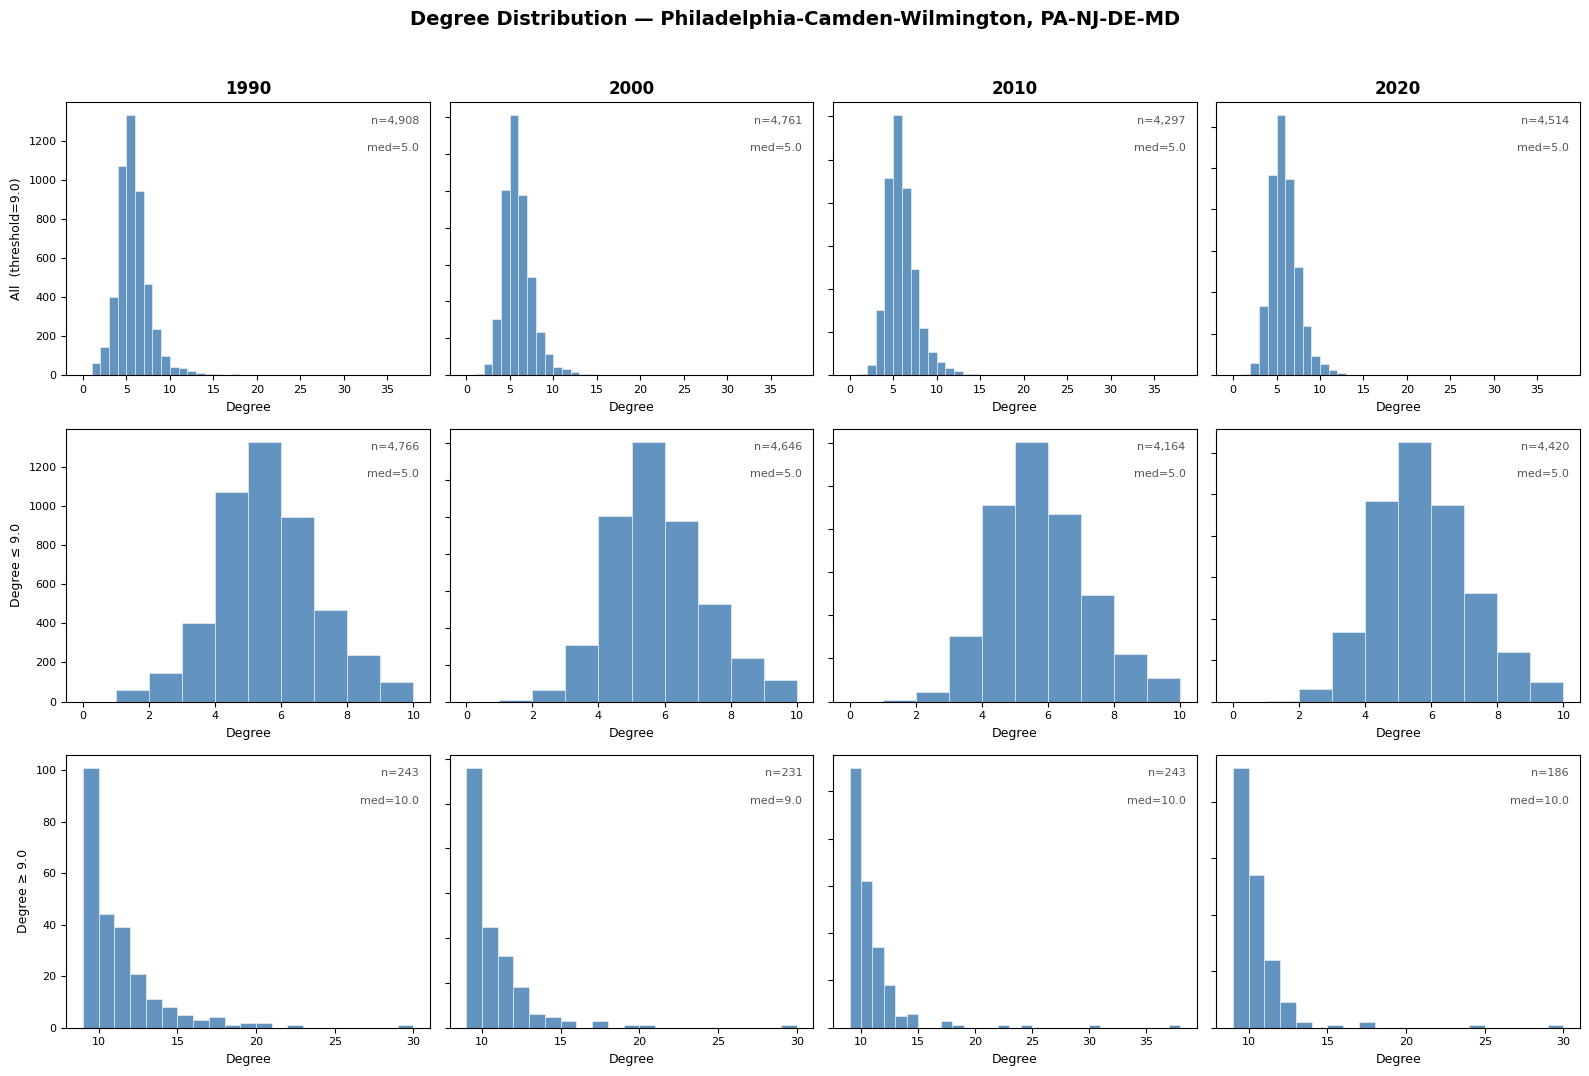


Degree statistics by year — Philadelphia-Camden-Wilmington, PA-NJ-DE-MD  (Tukey threshold = 9.0)
  Year   Leaves      Mean    Median    Min    Max       Std
------------------------------------------------------------
  1990       61      5.30      5.00      1     29      1.98
  2000        7      5.45      5.00      1     29      1.76
  2010        5      5.50      5.00      1     37      1.90
  2020        4      5.40      5.00      1     29      1.69


In [190]:

plot_degree_distribution(CBSA)

Saved Figures/City Profile Figures/Philadelphia_bg_city_profile/cbsa_37980_1990_Black_Share_graph.png


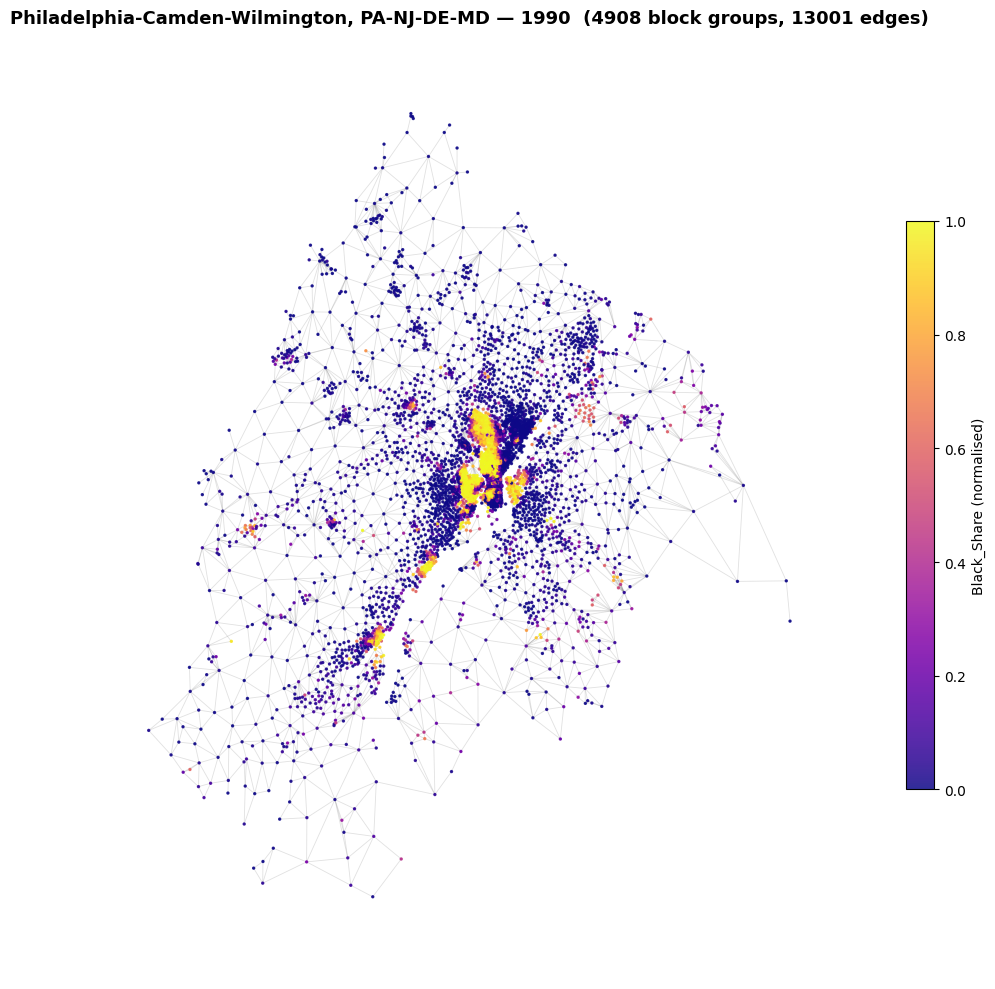

Saved Figures/City Profile Figures/Philadelphia_bg_city_profile/cbsa_37980_2000_Black_Share_graph.png


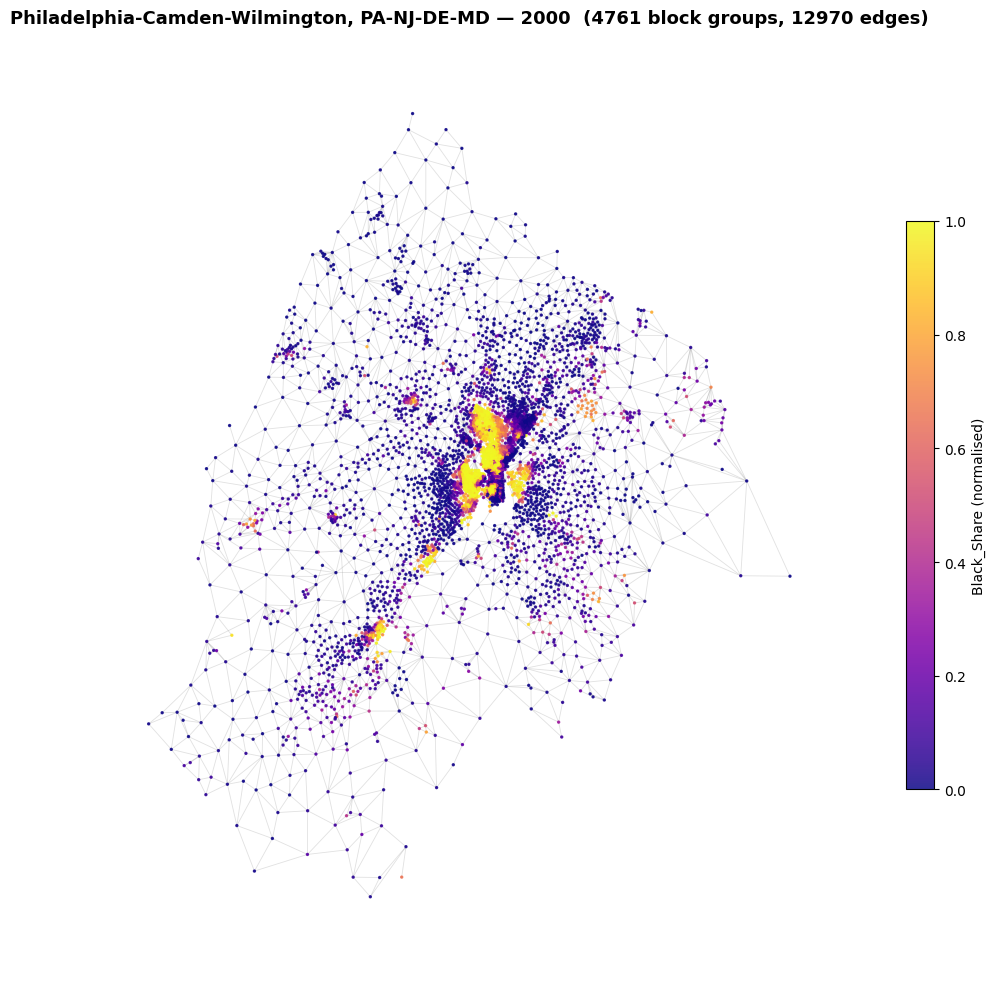

Saved Figures/City Profile Figures/Philadelphia_bg_city_profile/cbsa_37980_2010_Black_Share_graph.png


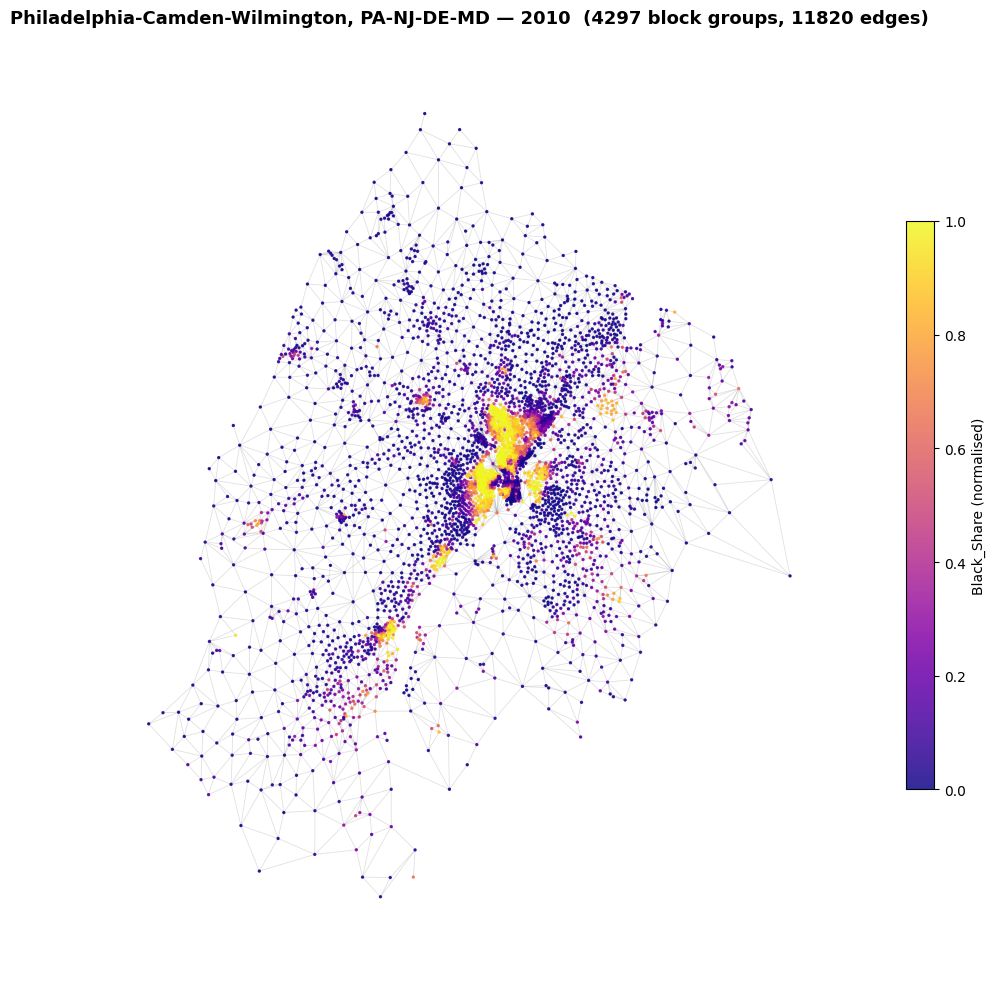

Saved Figures/City Profile Figures/Philadelphia_bg_city_profile/cbsa_37980_2020_Black_Share_graph.png


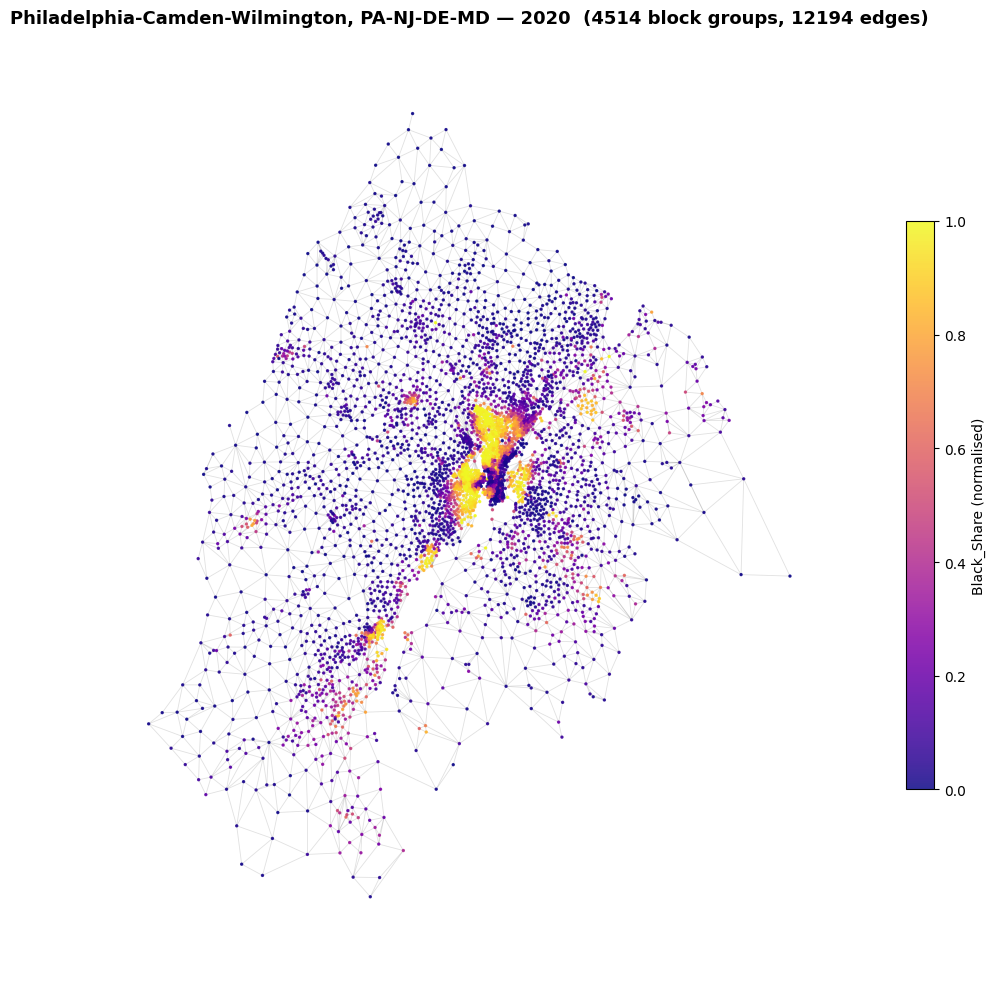


Graph report — Philadelphia-Camden-Wilmington, PA-NJ-DE-MD

Graph Structure
  Year   Nodes   Edges
----------------------
  1990    4908   13001
  2000    4761   12970
  2010    4297   11820
  2020    4514   12194

Black Share  (BLACK / (BLACK + WHITE))
  Year        Mean      Median         Min         Max         Std
---------------------------------------------------------------
  1990      0.2532      0.0339      0.0000      1.0000      0.3675
  2000      0.2991      0.0750      0.0000      1.0000      0.3724
  2010      0.2947      0.0954      0.0000      1.0000      0.3532
  2020      0.2901      0.1116      0.0000      1.0000      0.3353

POC Share  (POC / TOTPOP)
  Year        Mean      Median         Min         Max         Std
---------------------------------------------------------------
  1990      0.2900      0.0783      0.0000      1.0000      0.3647
  2000      0.3606      0.1635      0.0000      1.0000      0.3632
  2010      0.3851      0.2290      0.0000      1.0000

In [191]:
# Graph without shapefile (spring layout)
plot_graph(CBSA, var = "Black_Share", overlay_shapefile=False)

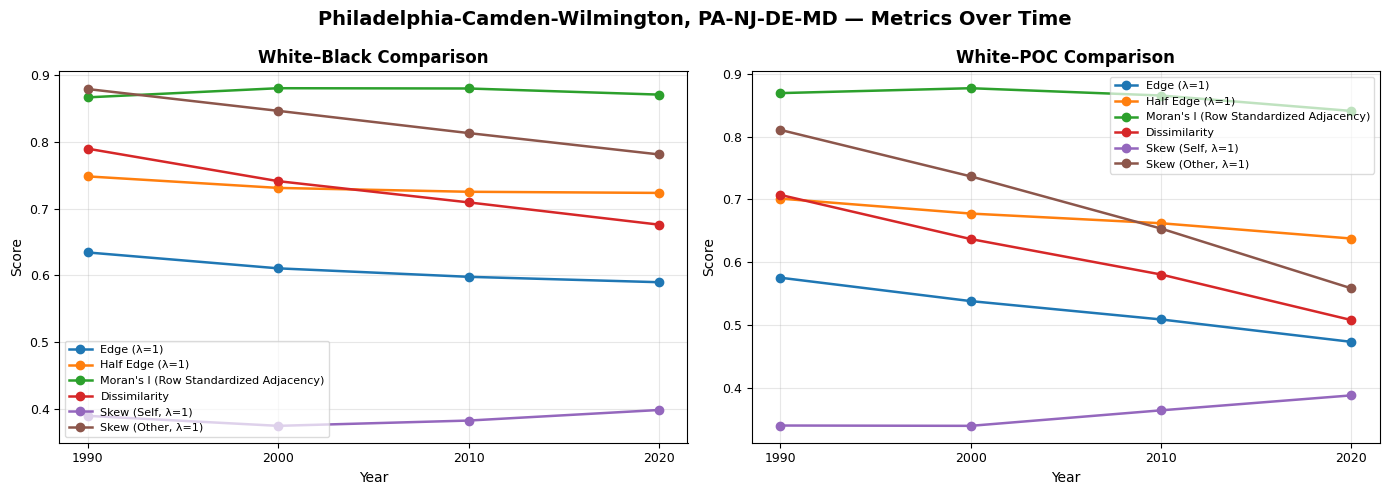

Philadelphia-Camden-Wilmington, PA-NJ-DE-MD — Score Report

White–Black Comparison
  Year           edge_1      half_edge_1          moran_P  dissimilarity_1      skew_self_1     skew_other_1
------------------------------------------------------------------------------------------------------------
  1990           0.6343           0.7482           0.8666           0.7897           0.3897           0.8790
  2000           0.6105           0.7310           0.8802           0.7411           0.3747           0.8464
  2010           0.5978           0.7252           0.8798           0.7093           0.3826           0.8131
  2020           0.5898           0.7235           0.8707           0.6760           0.3984           0.7811
------------------------------------------------------------------------------------------------------------
  Mean           0.6081           0.7320           0.8743           0.7290           0.3864           0.8299
Median           0.6042           0.7281     

In [192]:
metrics = ["edge_1", "half_edge_1", "moran_P", "dissimilarity_1", "skew_self_1", "skew_other_1"]

plot_score_graph(CBSA, metrics)

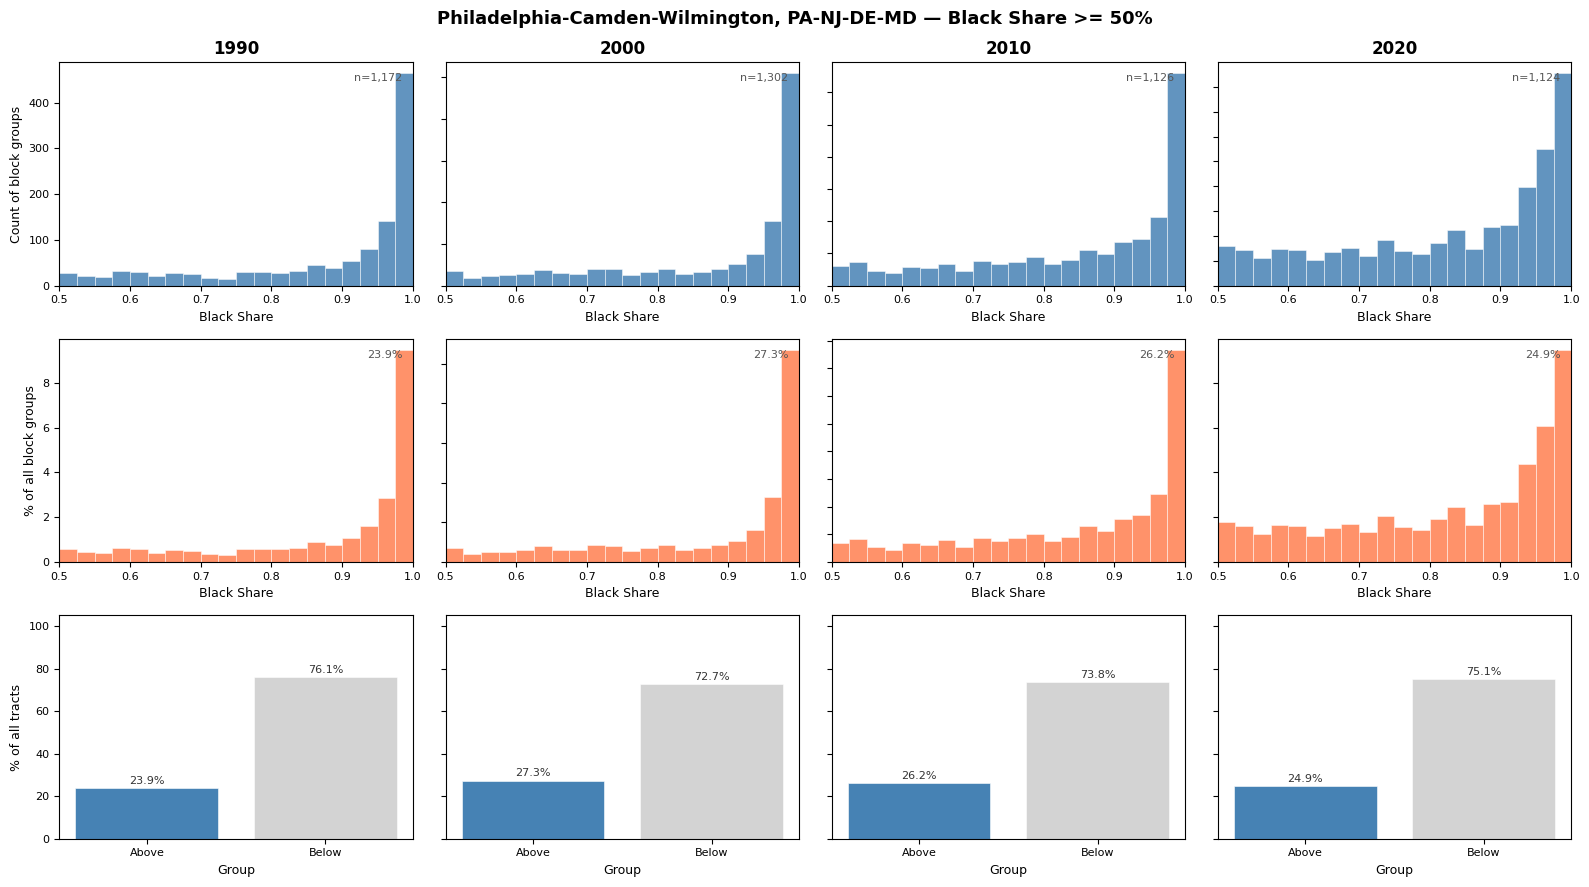

Philadelphia-Camden-Wilmington, PA-NJ-DE-MD — Black Share threshold report (>= 50%)
  Year   Total   Above       Pct      Cutoff
--------------------------------------------
  1990    4908    1172    23.88%      0.5000
  2000    4761    1302    27.35%      0.5000
  2010    4297    1126    26.20%      0.5000
  2020    4514    1124    24.90%      0.5000
Saved Figures/City Profile Figures/Philadelphia_bg_city_profile/cbsa_37980_black_maj_threshold_report.txt


In [193]:
plot_threshold_counts(CBSA, comparison='black', threshold='maj')
# plot_threshold_counts(CBSA, comparison='poc', threshold='avg')